In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model17_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model17_0)
describe(model17_0)

MACs: 5.85 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model17_0.pt
Starting
Epoch 1/60: Train loss = 1.1454, Train accuracy = 0.5945, Test loss = 1.1180, Test accuracy = 0.6065
Epoch 2/60: Train loss = 0.9142, Train accuracy = 0.6789, Test loss = 0.9050, Test accuracy = 0.6875
Epoch 3/60: Train loss = 0.7546, Train accuracy = 0.7357, Test loss = 0.7734, Test accuracy = 0.7308
Epoch 4/60: Train loss = 0.7812, Train accuracy = 0.7281, Test loss = 0.7966, Test accuracy = 0.7270
Epoch 5/60: Train loss = 0.7427, Train accuracy = 0.7414, Test loss = 0.7528, Test accuracy = 0.7417
Epoch 6/60: Train loss = 0.7006, Train accuracy = 0.7583, Test loss = 0.7044, Test accuracy = 0.7586
Epoch 7/60: Train loss = 0.6385, Train accuracy = 0.7814, Test loss = 0.6596, Test accuracy = 0.7795
Epoch 8/60: Train loss = 0.6545, Train accuracy = 0.7726, Test loss = 0.6699, Test accuracy = 0.7768
Epoch 9/60: Train loss = 0.5671, Train accuracy = 0.8007, Test loss = 0.5975, Test accuracy = 0.7944
Epoch 10/60: Train loss = 0.622

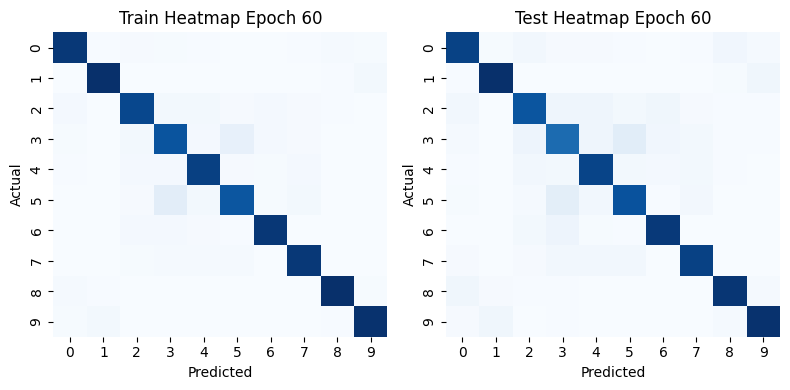

<Figure size 1200x600 with 0 Axes>

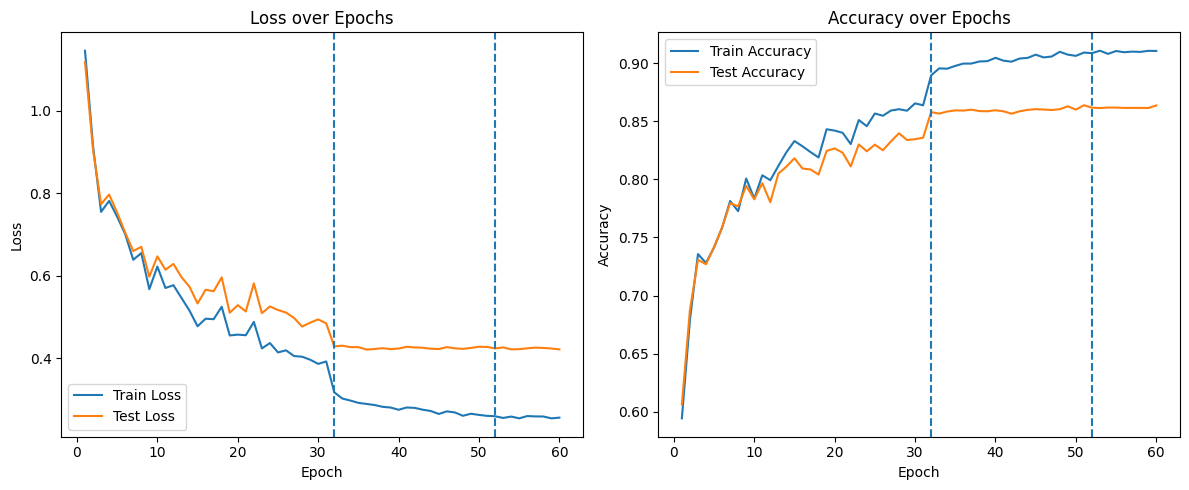

In [6]:
trainf32(model17_0,"model_weights/model17_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model17_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model17_1)
describe(model17_1)

MACs: 5.85 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.0521, Train accuracy = 0.6353, Test loss = 1.0202, Test accuracy = 0.6524
Epoch 2/60: Train loss = 0.8703, Train accuracy = 0.6963, Test loss = 0.8365, Test accuracy = 0.7114
Epoch 3/60: Train loss = 0.7617, Train accuracy = 0.7303, Test loss = 0.7916, Test accuracy = 0.7219
Epoch 4/60: Train loss = 0.7281, Train accuracy = 0.7470, Test loss = 0.7455, Test accuracy = 0.7439
Epoch 5/60: Train loss = 0.6621, Train accuracy = 0.7685, Test loss = 0.6694, Test accuracy = 0.7636
Epoch 6/60: Train loss = 0.6798, Train accuracy = 0.7629, Test loss = 0.7023, Test accuracy = 0.7615
Epoch 7/60: Train loss = 0.5615, Train accuracy = 0.8036, Test loss = 0.6092, Test accuracy = 0.7916
Epoch 8/60: Train loss = 0.5932, Train accuracy = 0.7923, Test loss = 0.6367, Test accuracy = 0.7790
Epoch 9/60: Train loss = 0.5568, Train accuracy = 0.8074, Test loss = 0.5800, Test accuracy = 0.8047
Epoch 10/60: Train loss = 0.5723, Train accuracy = 0.8040, Test loss = 0.6258, Test accurac

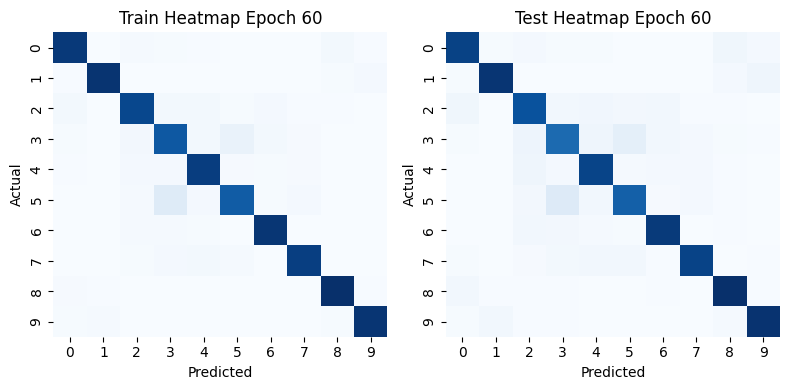

<Figure size 1200x600 with 0 Axes>

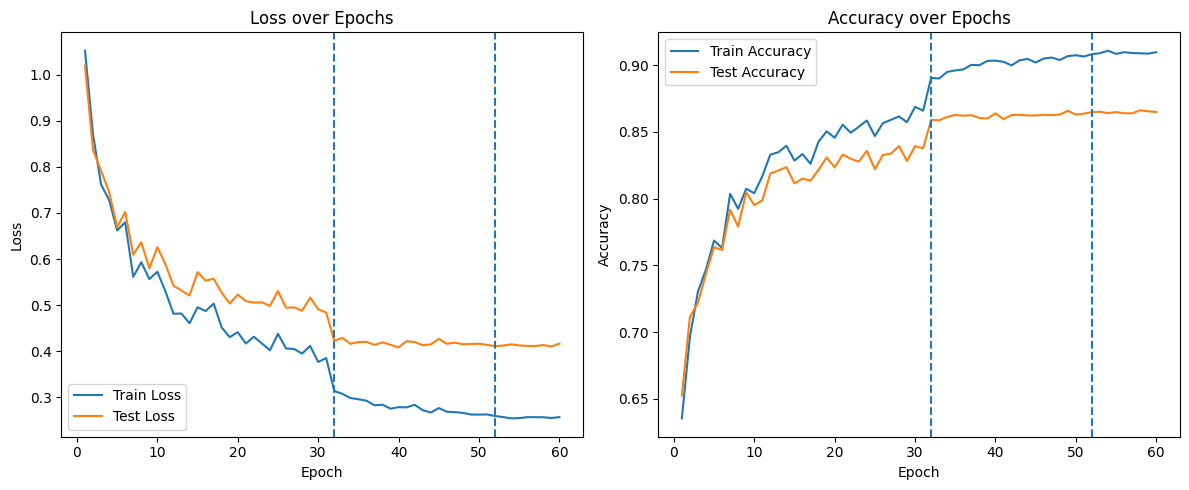

In [8]:
trainf32(model17_1,"model_weights/model17_1.pt",criterion,train_dataset,val_dataset, batch_size=64)